In [1]:
import pickle as pkl
import numpy as np

train_data  = np.load('mydata/train.npy', allow_pickle=True)

In [2]:
first_sample = train_data[0]

In [3]:
with open('mydata/network_porto/porto_edges_new_simplify.pkl', 'rb') as f:
    edgeinfo = pkl.load(f)
with open('mydata/network_porto/porto_nodes_new.pkl', 'rb') as f:
    nodeinfo = pkl.load(f)

In [4]:
print(edgeinfo[0])
print(nodeinfo['25503936'])

['motorway_link', 32.3884588871153, '25503936', '4722746638']
(-8.6406364, 41.1660713, 3.0)


In [5]:
import torch
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import Dataset

In [6]:
highway = {'living_street':1, 'morotway':2, 'motorway_link':3, 'plannned':4, 'trunk':5, "secondary":6, "trunk_link":7, "tertiary_link":8, "primary":9, "residential":10, "primary_link":11, "unclassified":12, "tertiary":13, "secondary_link":14}


In [7]:
def collate(data):

    # trip-level time
    day_of_week = np.array([d[2] for d in data], dtype=np.int16)
    day_of_year = np.array([d[3] for d in data], dtype=np.int16)
    minute_of_day = np.array([d[4] for d in data], dtype=np.int16)

    travel_time = np.array([d[-1] for d in data], dtype=np.float32)

    linkids = []
    inds = []
    for _, l in enumerate(data):
        linkids.append(np.asarray(l[1]))
        inds.append(l[0])
    lens = np.asarray([len(k) for k in linkids], dtype=np.int16)
    def info(xs):
        length = 0
        for x in xs:
            length += edgeinfo[x][1]
            
            # highway length sumoflength gps4

        return length
    lengths = np.asarray([info(b) for b in linkids], dtype=np.float32)
    return {
        'day_of_week': day_of_week,
        'day_of_year': day_of_year,
        'minute_of_day': minute_of_day,
        'lengths': lengths, 
    }, travel_time

In [8]:

class Datadict(Dataset):
    def __init__(self, inputs):
        self.content = inputs

    def __getitem__(self, idx):
        return self.content[idx]

    def __len__(self):
        return len(self.content)

loader = DataLoader(Datadict(train_data), batch_size=16, collate_fn=collate, pin_memory=True, shuffle=False)


In [9]:
import torch
import torch.nn as nn
import math

class PositionalEncoding1D(nn.Module):
    def __init__(self, d_model: int = 256):
        """
        Args:
            d_model (int): Total dimensionality of the encoding.
                           Must be divisible by 2.
        """
        super().__init__()
        if d_model % 2 != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by 2.")
        
        self.d_model = d_model
        self.d_half = d_model // 2

        # 10000^(2i / d_model)
        div_term = torch.exp(
            torch.arange(0, self.d_half, 2).float()
            * (-math.log(10000.0) / self.d_half)
        )

        self.register_buffer("div_term", div_term)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): shape (batch_size,) or (batch_size, 1)
                              continuous values (e.g., time, distance)

        Returns:
            torch.Tensor: shape (batch_size, d_model)
        """
        if x.dim() == 1:
            x = x.unsqueeze(1)  # (B, 1)

        # (B, 1) * (d_half/2) → (B, d_half/2)
        x_arg = x * self.div_term

        pe_sin = torch.sin(x_arg)
        pe_cos = torch.cos(x_arg)

        # (B, d_model)
        pe = torch.cat([pe_sin, pe_cos], dim=1)
        return pe

In [10]:
dow_model = PositionalEncoding1D(d_model=16)
doy_model = PositionalEncoding1D(d_model=16)
minute_model = PositionalEncoding1D(d_model=16)

In [11]:
from tqdm import tqdm
dow_all = []
doy_all = []
minute_all = []
time_all = []
length_all = []
pe_dow_all = []
pe_doy_all = []
pe_minute_all = []
with torch.no_grad():
    for batch, travel_time in loader:
        dow_all.append(batch['day_of_week'])
        doy_all.append(batch['day_of_year'])
        minute_all.append(batch['minute_of_day'])
        length_all.append(batch['lengths'])
        
        dow_tensor = torch.from_numpy(batch['day_of_week'])
        doy_tensor = torch.from_numpy(batch['day_of_year'])
        minute_tensor = torch.from_numpy(batch['minute_of_day'])
        
        pe_dow_all.append(dow_model(dow_tensor).numpy())
        pe_doy_all.append(doy_model(doy_tensor).numpy())
        pe_minute_all.append(minute_model(minute_tensor).numpy())
        
        time_all.append(travel_time)

dow = np.concatenate(dow_all)
doy = np.concatenate(doy_all)
minute = np.concatenate(minute_all)
travel_time = np.concatenate(time_all)
lengths = np.concatenate(length_all)

pe_dow = np.concatenate(pe_dow_all)
pe_doy = np.concatenate(pe_doy_all)
pe_minute = np.concatenate(pe_minute_all)

In [12]:
print(dow.shape, doy.shape, minute.shape, travel_time.shape, lengths.shape, pe_dow.shape, pe_doy.shape, pe_minute.shape)

(900877,) (900877,) (900877,) (900877,) (900877,) (900877, 8) (900877, 8) (900877, 8)


In [13]:
np.savez(
    "trip_time_features.npz",
    day_of_week=dow,
    day_of_year=doy,
    minute_of_day=minute,
    travel_time=travel_time,
    lengths=lengths
)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("trip_time_features.npz")

dow = data["day_of_week"]
doy = data["day_of_year"]
minute = data["minute_of_day"]
travel_time = data["travel_time"]
length = data["lengths"]

print(dow.shape, doy.shape, minute.shape, travel_time.shape, length.shape)

(900877,) (900877,) (900877,) (900877,) (900877,)


C:\Users\atom0\AppData\Local\Temp\ipykernel_17384\916842309.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


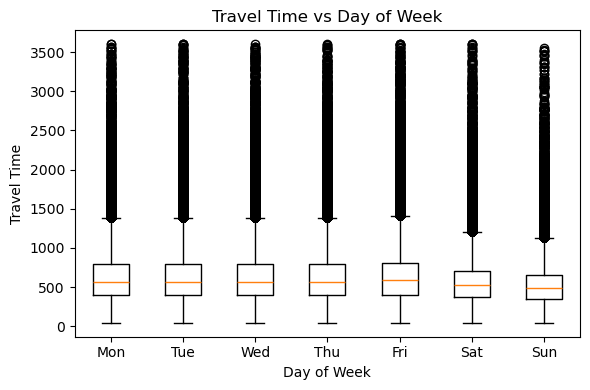

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [travel_time[dow == i] for i in range(7)],
    labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)
plt.xlabel("Day of Week")
plt.ylabel("Travel Time")
plt.title("Travel Time vs Day of Week")
plt.tight_layout()
plt.show()

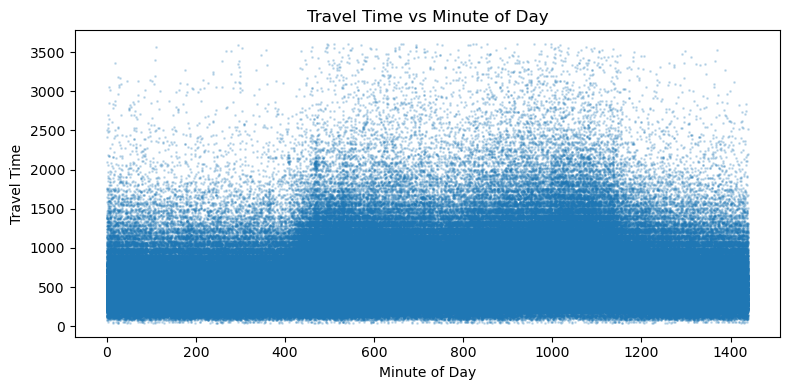

In [16]:
plt.figure(figsize=(8,4))
plt.scatter(minute, travel_time, s=1, alpha=0.2)
plt.xlabel("Minute of Day")
plt.ylabel("Travel Time")
plt.title("Travel Time vs Minute of Day")
plt.tight_layout()
plt.show()

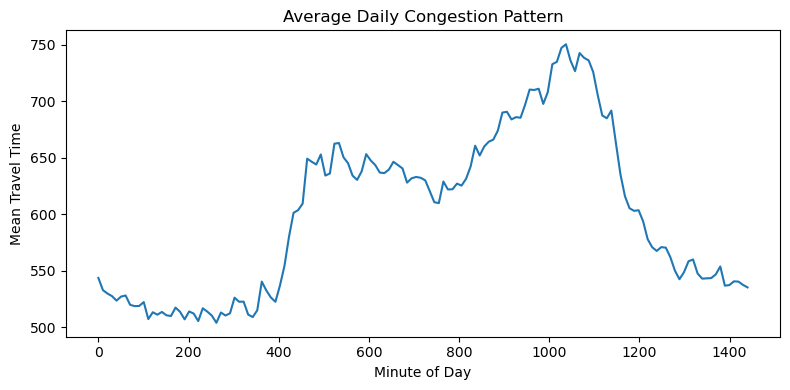

In [17]:
bins = 144  # 10-minute bins
bin_ids = (minute / (1440 / bins)).astype(int)

mean_tt = np.zeros(bins)
for i in range(bins):
    mean_tt[i] = travel_time[bin_ids == i].mean()

plt.figure(figsize=(8,4))
plt.plot(np.linspace(0, 1440, bins), mean_tt)
plt.xlabel("Minute of Day")
plt.ylabel("Mean Travel Time")
plt.title("Average Daily Congestion Pattern")
plt.tight_layout()
plt.show()

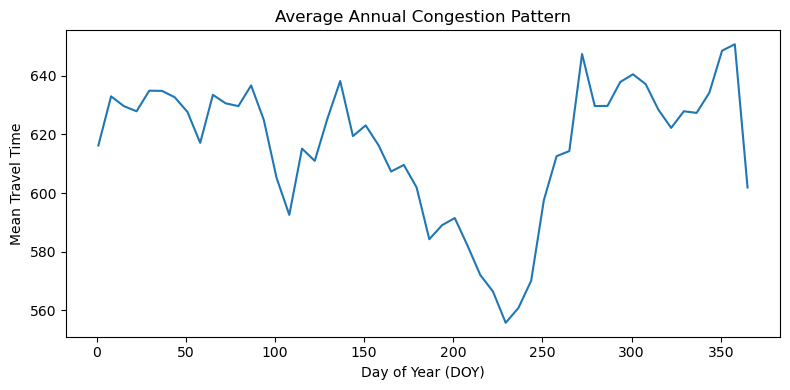

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử 'doy' và 'travel_time' là mảng numpy của bạn
# doy thường có giá trị từ 1 đến 365 (hoặc 366 cho năm nhuận)

bins = int(365 / 7) # Chia thành các khoảng 5 ngày (365 / 5 = 73 bins) để làm mượt biểu đồ

# Trừ 1 để đưa doy về dạng 0-indexed (0 đến 364), tránh lỗi out of bounds
bin_ids = ((doy - 1) / (365 / bins)).astype(int)

# Đảm bảo bin_ids không vượt quá giới hạn (ví dụ: năm nhuận có ngày 366)
bin_ids = np.clip(bin_ids, 0, bins - 1)

mean_tt = np.zeros(bins)
for i in range(bins):
    # Lấy trung bình, bỏ qua cảnh báo nếu có bin trống bằng nanmean
    mask = (bin_ids == i)
    if mask.any():
        mean_tt[i] = travel_time[mask].mean()
    else:
        mean_tt[i] = np.nan # Gán NaN nếu khoảng 5 ngày đó không có dữ liệu

plt.figure(figsize=(8,4))
# Trục X chạy từ ngày 1 đến 365
plt.plot(np.linspace(1, 365, bins), mean_tt)
plt.xlabel("Day of Year (DOY)")
plt.ylabel("Mean Travel Time")
plt.title("Average Annual Congestion Pattern")
plt.tight_layout()
plt.show()

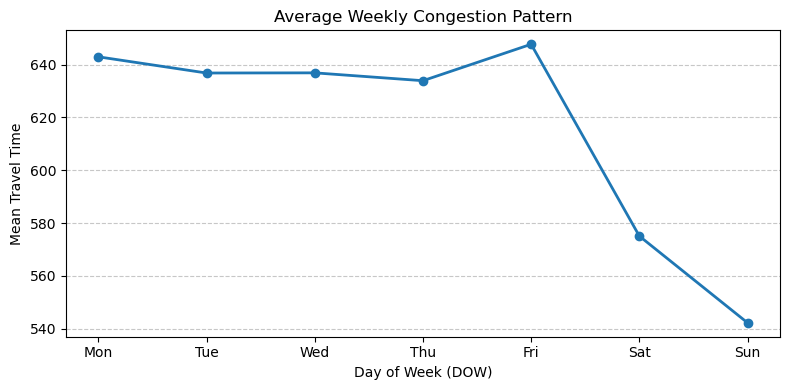

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử 'dow' là mảng chứa giá trị từ 0 (Thứ 2) đến 6 (Chủ Nhật)
days = np.arange(7)
mean_tt = np.zeros(7)

for i in range(7):
    # Lấy trung bình thời gian di chuyển cho từng ngày trong tuần
    mean_tt[i] = travel_time[dow == i].mean()

plt.figure(figsize=(8,4))
# Vẽ biểu đồ đường có đánh dấu điểm (marker) để thấy rõ sự rời rạc
plt.plot(days, mean_tt, marker='o', linestyle='-', linewidth=2)

# Đổi nhãn trục X thành tên ngày cho trực quan
plt.xticks(days, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xlabel("Day of Week (DOW)")
plt.ylabel("Mean Travel Time")
plt.title("Average Weekly Congestion Pattern")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

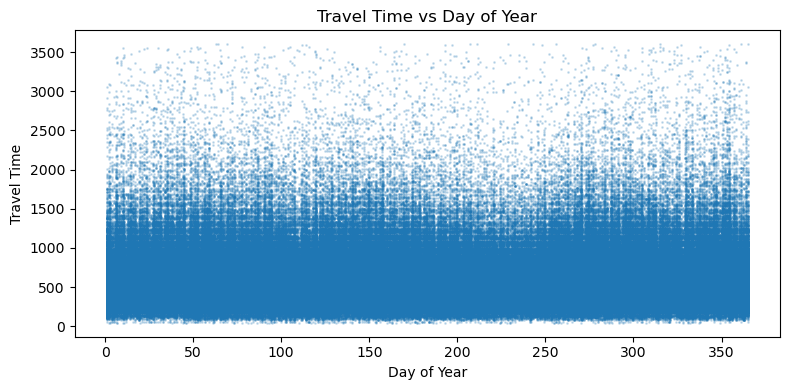

In [18]:
plt.figure(figsize=(8,4))
plt.scatter(doy, travel_time, s=1, alpha=0.2)
plt.xlabel("Day of Year")
plt.ylabel("Travel Time")
plt.title("Travel Time vs Day of Year")
plt.tight_layout()
plt.show()

C:\Users\atom0\AppData\Local\Temp\ipykernel_17384\1533598328.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\atom0\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


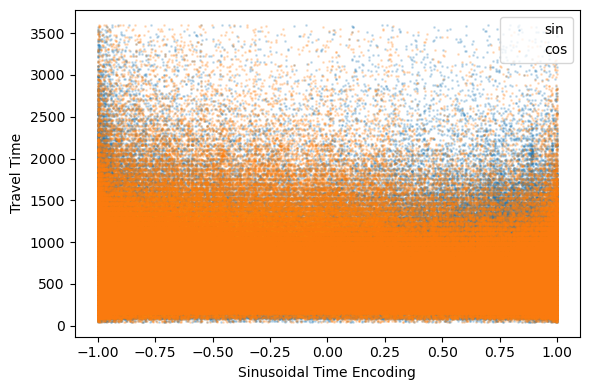

In [19]:
sin_time = np.sin(2 * np.pi * minute / 1440)
cos_time = np.cos(2 * np.pi * minute / 1440)

plt.figure(figsize=(6,4))
plt.scatter(sin_time, travel_time, s=1, alpha=0.2, label="sin")
plt.scatter(cos_time, travel_time, s=1, alpha=0.2, label="cos")
plt.xlabel("Sinusoidal Time Encoding")
plt.ylabel("Travel Time")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
time_bins = [
    ("Night (0–5h)", 0, 300),
    ("Morning (7–9h)", 420, 540),
    ("Midday (11–13h)", 660, 780),
    ("Evening (16–18h)", 960, 1080),
]

In [21]:
distance_mean = np.mean(length)
distance_std = np.std(length)
q1 = np.percentile(length, 25)
q3 = np.percentile(length, 75)

print(f"Distance Mean: {distance_mean:.2f}")
print(f"Distance Standard Deviation: {distance_std:.2f}")
print(f"Distance 25th Percentile: {q1:.2f}")
print(f"Distance 75th Percentile: {q3:.2f}")

Distance Mean: 4913.41
Distance Standard Deviation: 2976.85
Distance 25th Percentile: 2818.36
Distance 75th Percentile: 6182.82


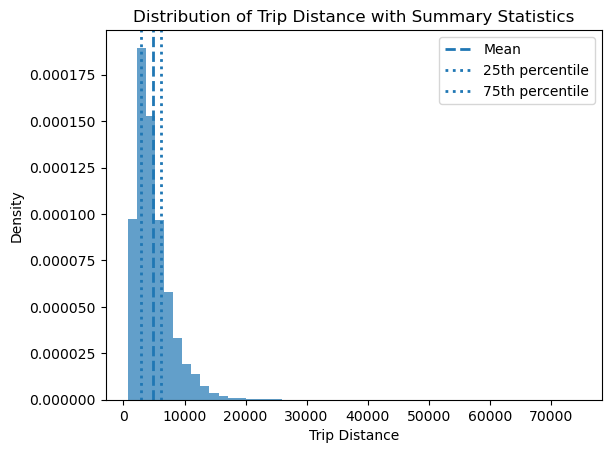

In [22]:
plt.figure()
plt.hist(length, bins=50, density=True, alpha=0.7)
plt.axvline(distance_mean, linestyle='--', linewidth=2, label='Mean')
plt.axvline(q1, linestyle=':', linewidth=2, label='25th percentile')
plt.axvline(q3, linestyle=':', linewidth=2, label='75th percentile')

plt.xlabel("Trip Distance")
plt.ylabel("Density")
plt.title("Distribution of Trip Distance with Summary Statistics")
plt.legend()
plt.show()